# Tutorial 06 — FastRelax

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/master/docs/tutorial/06_fast_relax.ipynb)

TMol `fast_relax()` alternates side-chain repacking and minimization under a changing score-function schedule.

## Learning objectives

- Prepare a packing palette, move map, and fold forest.
- Run one short repeat and inspect the weight schedule.
- Compare the input, stage endpoints, and accepted result.

## Before you begin

- **Prerequisites:** Both [04 — Packing](04_packing_and_mutation_scan.ipynb) and [05 — Minimization](05_minimization_constraints_kinematics.ipynb).
- **Curriculum:** This rejoins the two branches after 03 and completes the core 01 → 06 path. Continue with specialized [07 — Ligands](07_ligand_and_params.ipynb) and [08 — Nucleic acids](08_nucleic_acids.ipynb).
- **Related:** [Optimization workflow](../user_guide/optimization.md) · [FastRelax API](../api/relax.rst)

TMol `fast_relax()` is Rosetta-inspired, but its scoring, search, and acceptance behavior differ. The short CPU run checks that the API works; it does not establish convergence. The larger batch example requires CUDA.

## Setup

The main example uses a checked-in six-residue 1UBQ slice, one repeat, and a two-stage schedule so it remains practical on CPU. The larger ensemble cell is tagged `gpu-only` and is executed by the GPU CI lane. Both are pedagogical smoke tests rather than production relaxation schedules.

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "master/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1UBQ.cif"])

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol.io import pose_stack_from_biotite
from tmol.kinematics import CartesianMoveMap, FoldForest, MoveMap
from tmol.pack import PackerPalette
from tmol.pose import PoseStackBuilder
from tmol.score import ScoreType, beta2016_score_function
from tmol.score.constraint import create_mainchain_coordinate_constraints

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings(
    "ignore", message=r"Sparse invariant checks are implicitly disabled.*"
)
device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)

# Strictly a smoke-test budget shared by every minimizer in this tutorial,
# including the GPU batch. Finite output is not evidence of convergence.
TUTORIAL_MAX_ITER = 10


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


def score_components_by_pose(pose_stack, score_function):
    scorer = score_function.render_whole_pose_scoring_module(pose_stack)
    weighted_terms = scorer(
        pose_stack.coords, sum_terms=False, apply_weights=True
    )
    score_types = score_function.all_score_types()
    total_scores = weighted_terms.sum(dim=0)
    constraint_index = next(
        (
            index
            for index, score_type in enumerate(score_types)
            if score_type == ScoreType.constraint
        ),
        None,
    )
    constraint_scores = (
        torch.zeros_like(total_scores)
        if constraint_index is None
        else weighted_terms[constraint_index]
    )
    non_constraint_scores = total_scores - constraint_scores
    return [
        {
            "non_constraint_score_units": float(non_constraint_scores[i].detach().cpu()),
            "constraint_score_units": float(constraint_scores[i].detach().cpu()),
            "reported_total_score_units": float(total_scores[i].detach().cpu()),
        }
        for i in range(pose_stack.n_poses)
    ]


def score_components(pose_stack, score_function):
    if pose_stack.n_poses != 1:
        raise ValueError("Use score_components_by_pose() for batched PoseStacks.")
    return score_components_by_pose(pose_stack, score_function)[0]


def common_atom_mask(reference, mobile):
    return torch.isfinite(reference.coords).all(dim=-1) & torch.isfinite(
        mobile.coords
    ).all(dim=-1)


def rms_displacement(reference, mobile):
    """Raw all-atom RMS displacement in the input coordinate frame."""
    mask = common_atom_mask(reference, mobile)
    delta = mobile.coords[mask] - reference.coords[mask]
    return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


def kabsch_aligned_rmsd(reference, mobile):
    """All-atom RMSD after least-squares rigid-body superposition."""
    mask = common_atom_mask(reference, mobile)
    reference_xyz = reference.coords[mask]
    mobile_xyz = mobile.coords[mask]
    reference_centered = reference_xyz - reference_xyz.mean(dim=0)
    mobile_centered = mobile_xyz - mobile_xyz.mean(dim=0)
    covariance = mobile_centered.T @ reference_centered
    u, _, vh = torch.linalg.svd(covariance)
    handedness = torch.sign(torch.det(u @ vh))
    correction = torch.eye(3, device=mobile_xyz.device, dtype=mobile_xyz.dtype)
    correction[-1, -1] = handedness
    rotation = u @ correction @ vh
    delta = mobile_centered @ rotation - reference_centered
    return float(torch.sqrt(torch.mean(torch.sum(delta * delta, dim=-1))).cpu())


def declared_mainchain_atom_mask(pose_stack):
    """Select atoms named in each residue type's TMol polymer declaration."""
    mask = torch.zeros_like(pose_stack.real_atoms)
    atom_names = []
    seen_atom_names = set()
    for pose_index in range(pose_stack.n_poses):
        for block_index in range(pose_stack.max_n_blocks):
            block_type_index = int(
                pose_stack.block_type_ind64[pose_index, block_index].item()
            )
            if block_type_index < 0:
                continue
            block_type = pose_stack.packed_block_types.active_block_types[
                block_type_index
            ]
            polymer = block_type.properties.polymer
            if polymer is None:
                continue
            atom_offset = int(
                pose_stack.block_coord_offset64[pose_index, block_index].item()
            )
            for atom_name in polymer.mainchain_atoms:
                atom_index = atom_offset + block_type.atom_to_idx[atom_name]
                if bool(pose_stack.real_atoms[pose_index, atom_index]):
                    mask[pose_index, atom_index] = True
                    if atom_name not in seen_atom_names:
                        atom_names.append(atom_name)
                        seen_atom_names.add(atom_name)
    return mask, tuple(atom_names)


def coordinates_equal(first, second):
    if first.coords.shape != second.coords.shape:
        return False
    first_finite = torch.isfinite(first.coords)
    second_finite = torch.isfinite(second.coords)
    return (
        torch.equal(first.block_type_ind64, second.block_type_ind64)
        and torch.equal(first_finite, second_finite)
        and torch.equal(first.coords[first_finite], second.coords[second_finite])
    )

## Protocol and ramp schedule

`tmol.fast_relax()` alternates side-chain repacking and minimization while increasing the `fa_rep` weight. A `CartesianMoveMap` selects Cartesian coordinates. A `MoveMap`, `FoldForest`, and custom minimizer select kinematic degrees of freedom.

The default protocol uses four stages and two repeats. This tutorial uses two stages, one repeat, and ten minimizer iterations so it runs as a smoke test. Finite output shows that the workflow executes; it does not establish convergence.

Coordinate constraints are attached before relaxation. Each schedule entry scales the starting repulsive and constraint weights, and the final minimization uses full repulsion.

In [3]:
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol" / "tests" / "data" / "cif" / "1UBQ.cif"
atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 6)]
setup_diagnostics = StringIO()
try:
    with redirect_stdout(setup_diagnostics), redirect_stderr(setup_diagnostics):
        pose = pose_stack_from_biotite(protein_slice, device, no_optH=True)
        relax_start = create_mainchain_coordinate_constraints(pose)
except Exception:
    print(setup_diagnostics.getvalue())
    raise

score_function = beta2016_score_function(device)
score_function.set_weight(ScoreType.constraint, 1.0)
fa_rep_start = float(score_function.get_weight(ScoreType.fa_ljrep))
constraint_start = float(score_function.get_weight(ScoreType.constraint))
mainchain_mask, restrained_atom_names = declared_mainchain_atom_mask(relax_start)
CONSTRAINT_SIGMA_A = 0.5

palette = PackerPalette()
cartesian_move_map = CartesianMoveMap()
fold_forest = FoldForest.reasonable_fold_forest(relax_start)
tiny_schedule = [
    {"fa_rep_pack_frac": 0.10, "fa_rep_min_frac": 0.20, "cst_frac": 1.0},
    {"fa_rep_pack_frac": 1.00, "fa_rep_min_frac": 1.00, "cst_frac": 0.0},
]

schedule_table = pd.DataFrame(tiny_schedule)
schedule_table["fa_rep_pack_weight"] = (
    schedule_table["fa_rep_pack_frac"] * fa_rep_start
)
schedule_table["fa_rep_min_weight"] = (
    schedule_table["fa_rep_min_frac"] * fa_rep_start
)
schedule_table["constraint_weight"] = schedule_table["cst_frac"] * constraint_start
print("input:", cif_path.name)
print("coordinate-restraint atom names:", ", ".join(restrained_atom_names))
print("coordinate-restraint count:", int(mainchain_mask.sum().item()))
print(f"coordinate-restraint sigma: {CONSTRAINT_SIGMA_A:.1f} Å")
print(f"coordinate-restraint score weight: {constraint_start:.1f}")
print("O is not TMol-declared main chain here and is not constrained.")
print("Weight 1.0 is intentional; Rosetta comparisons commonly use 0.5.")
show_table(schedule_table)

input: 1UBQ.cif
coordinate-restraint atom names: N, CA, C
coordinate-restraint count: 18
coordinate-restraint sigma: 0.5 Å
coordinate-restraint score weight: 1.0
O is not TMol-declared main chain here and is not constrained.
Weight 1.0 is intentional; Rosetta comparisons commonly use 0.5.


## Run one repeat

The first stage uses reduced repulsion and the final stage restores full repulsion. The fold forest is passed through the shared protocol API, although the Cartesian minimizer does not use it.

The custom minimizer records the score immediately before and after each short minimization. These values help inspect the workflow, but they are not a convergence test.

In [4]:
def tutorial_cart_min(
    pose_stack, stage_score_function, *, fold_forest, move_map, verbose
):
    del fold_forest
    coord_mask = move_map.coord_mask if isinstance(move_map, CartesianMoveMap) else None
    return tmol.run_cart_min(
        pose_stack,
        stage_score_function,
        coord_mask=coord_mask,
        verbose=verbose,
        optimizer_kwargs={
            "max_iter": TUTORIAL_MAX_ITER,
            "verbose": verbose,
        },
    )


relax_stage_records = []


def recording_cart_min(
    pose_stack, stage_score_function, *, fold_forest, move_map, verbose
):
    constraint_weight = float(
        stage_score_function.get_weight(ScoreType.constraint)
    )
    objective_before = score_components(
        pose_stack, stage_score_function
    )["reported_total_score_units"]
    minimized = tutorial_cart_min(
        pose_stack,
        stage_score_function,
        fold_forest=fold_forest,
        move_map=move_map,
        verbose=verbose,
    )
    objective_after = score_components(
        minimized, stage_score_function
    )["reported_total_score_units"]
    relax_stage_records.append(
        {
            "pose": minimized.clone(),
            "constraint_weight_at_optimization": constraint_weight,
            "objective_before_min_units": objective_before,
            "objective_after_min_units": objective_after,
            "objective_change_during_min_units": objective_after - objective_before,
        }
    )
    return minimized


print(
    f"smoke-test optimizer max_iter: {TUTORIAL_MAX_ITER} "
    "(convergence not assessed)"
)
before_components = score_components(relax_start, score_function)
TUTORIAL_NUM_REPEATS = 1
relaxed = tmol.fast_relax(
    relax_start,
    score_function,
    palette,
    cartesian_move_map,
    fold_forest,
    num_repeats=TUTORIAL_NUM_REPEATS,
    schedule=tiny_schedule,
    ramp_constraints=True,
    min_fn=recording_cart_min,
    verbose=False,
)
assert torch.isfinite(relaxed.coords[relaxed.real_atoms]).all()
after_components = score_components(relaxed, score_function)

if coordinates_equal(relaxed, relax_start):
    accepted_from = "input"
else:
    accepted_from = "unresolved (not an exact recorded repeat endpoint)"
    for repeat_index in range(TUTORIAL_NUM_REPEATS):
        record_index = (repeat_index + 1) * len(tiny_schedule) - 1
        if coordinates_equal(relaxed, relax_stage_records[record_index]["pose"]):
            accepted_from = (
                f"repeat {repeat_index + 1} endpoint "
                f"(stage {record_index + 1})"
            )
            break

score_frame = pd.DataFrame(
    [
        {
            "structure": "before",
            "accepted_from": "not applicable",
            **before_components,
        },
        {
            "structure": "accepted final",
            "accepted_from": accepted_from,
            **after_components,
        },
    ]
)
for component in (
    "non_constraint_score_units",
    "constraint_score_units",
    "reported_total_score_units",
):
    score_frame[f"{component.removesuffix('_units')}_change_units"] = (
        score_frame[component] - before_components[component]
    )
score_frame["finite_smoke_test_output"] = np.isfinite(
    score_frame[
        [
            "non_constraint_score_units",
            "constraint_score_units",
            "reported_total_score_units",
        ]
    ]
).all(axis=1)
score_frame["convergence_status"] = "not assessed (10-iteration smoke test)"
print("accepted final source:", accepted_from)
show_table(score_frame)

smoke-test optimizer max_iter: 10 (convergence not assessed)


accepted final source: repeat 1 endpoint (stage 2)


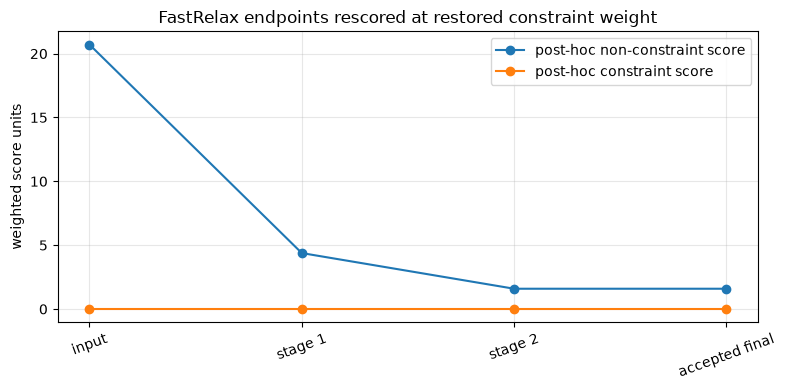

In [5]:
trajectory_structures = {"input": relax_start}
stage_metadata = {
    "input": {
        "constraint_weight_at_optimization": np.nan,
        "objective_before_min_units": np.nan,
        "objective_after_min_units": np.nan,
        "objective_change_during_min_units": np.nan,
    }
}
for stage_index, record in enumerate(relax_stage_records):
    label = f"stage {stage_index + 1}"
    trajectory_structures[label] = record["pose"]
    stage_metadata[label] = record
trajectory_structures["accepted final"] = relaxed
stage_metadata["accepted final"] = {
    "constraint_weight_at_optimization": np.nan,
    "objective_before_min_units": np.nan,
    "objective_after_min_units": np.nan,
    "objective_change_during_min_units": np.nan,
}

# fast_relax restores the starting constraint weight before returning. These
# scores are therefore a common post-hoc decomposition, not each stage's
# historical optimization objective.
posthoc_constraint_weight = float(
    score_function.get_weight(ScoreType.constraint)
)
trajectory_rows = []
trajectory_notes = {}
for frame_index, (label, frame_pose) in enumerate(trajectory_structures.items()):
    components = score_components(frame_pose, score_function)
    metadata = stage_metadata[label]
    raw_displacement = rms_displacement(relax_start, frame_pose)
    aligned_rmsd = kabsch_aligned_rmsd(relax_start, frame_pose)
    trajectory_rows.append(
        {
            "frame": frame_index,
            "label": label,
            "accepted_from": accepted_from if label == "accepted final" else "",
            "constraint_weight_at_optimization": metadata[
                "constraint_weight_at_optimization"
            ],
            "objective_before_min_units": metadata[
                "objective_before_min_units"
            ],
            "objective_after_min_units": metadata[
                "objective_after_min_units"
            ],
            "objective_change_during_min_units": metadata[
                "objective_change_during_min_units"
            ],
            "constraint_weight_for_posthoc_rescore": posthoc_constraint_weight,
            "raw_RMS_displacement_from_input_A": raw_displacement,
            "Kabsch_RMSD_from_input_A": aligned_rmsd,
            **components,
        }
    )
    optimized_weight = metadata["constraint_weight_at_optimization"]
    optimized_text = (
        "not a minimization endpoint"
        if np.isnan(optimized_weight)
        else (
            f"optimized cst weight {optimized_weight:.3f}; min objective change "
            f"{metadata['objective_change_during_min_units']:+.3f}"
        )
    )
    acceptance_text = (
        f"; accepted from {accepted_from}" if label == "accepted final" else ""
    )
    trajectory_notes[label] = (
        f"{optimized_text}; post-hoc non-constraint "
        f"{components['non_constraint_score_units']:.3f}; "
        f"constraint {components['constraint_score_units']:.3f}; "
        f"raw/aligned {raw_displacement:.3f}/{aligned_rmsd:.3f} Å"
        f"{acceptance_text}"
    )
trajectory_frame = pd.DataFrame(trajectory_rows)
show_table(trajectory_frame)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    trajectory_frame["frame"],
    trajectory_frame["non_constraint_score_units"],
    marker="o",
    label="post-hoc non-constraint score",
)
ax.plot(
    trajectory_frame["frame"],
    trajectory_frame["constraint_score_units"],
    marker="o",
    label="post-hoc constraint score",
)
ax.set(
    xticks=trajectory_frame["frame"],
    xticklabels=trajectory_frame["label"],
    ylabel="weighted score units",
    title="FastRelax endpoints rescored at restored constraint weight",
)
ax.tick_params(axis="x", rotation=20)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(
    tmol.switchable_view(
        trajectory_structures,
        notes=trajectory_notes,
    )
)

**Expected observations.** The non-constraint and constraint components, score changes, and structural metrics must be finite. “Non-constraint” is the exact description: it includes every weighted beta2016 term except the coordinate-constraint term, including empirical/statistical contributions. All reported values are weighted TMol score units, not kcal/mol. The raw metric retains coordinate-frame motion; Kabsch RMSD removes the best rigid-body superposition.

`fast_relax()` restores the starting constraint weight before returning. The table records the weight and objective change present during each stage's minimization separately from the restored weight used for the common post-hoc score decomposition. In particular, the final stage is optimized with `cst_frac=0`, but its displayed constraint penalty is recalculated afterward at full starting weight; it diagnoses restraint violation and is not part of that stage's optimization objective. The structure switcher records minimization endpoints for each pack/min stage and the final accept-to-best result; it does not contain LBFGS line-search evaluations or internal packing trajectories.

TMol's accept-best pool is **input-inclusive**: it initializes the best pose from the unrelaxed input and, after each complete schedule repeat, accepts that repeat endpoint only when its score is strictly lower. It does not accept among every intermediate stage. Consequently, a one-repeat run can legitimately return the exact input, and `accepted_from` explicitly distinguishes that case from the recorded repeat endpoint. This differs from Rosetta's usual FastRelax comparison among relaxed repeat outputs, where the unrelaxed input is not normally retained as an accept-best candidate.

There is an important custom-schedule caveat: the initial best score is captured with the weights present at protocol start, whereas `accept_best` scores a repeat endpoint with the weights left by the final schedule step. The tiny schedule here ends at full repulsion and zero constraint weight, and its restraints are built from the input coordinates, which masks that mismatch for this demonstration. For a custom schedule or initially violated restraints, rescore the input and repeat endpoints under one fixed weight set before interpreting which structure is better.

The `score_frame` and trajectory decomposition above are **matched-weight rescoring**: input, stage endpoints, and the accepted result are all evaluated after `fast_relax()` restores the same starting score-function weights. Historical per-stage objectives remain separate columns because those stages used different ramp weights. Compare structures only within one declared weight set; never subtract a low-repulsion stage objective from a full-repulsion endpoint and call the result an improvement.

A tiny pedagogical schedule is not guaranteed to improve every input. Large distortions, NaNs, or a missing ligand/residue are failures, not expected stochastic variation. Conversely, finite output or a favorable objective change under `max_iter=10` is only smoke-test evidence; convergence is not assessed.

## Convenience minimizers and precision boundary

`fast_relax` calls a custom minimizer as `min_fn(pose_stack, sfxn, *, fold_forest, move_map, verbose)`. The adapter below uses the supported top-level `tmol.run_kin_min(pose_stack, sfxn, ff, mm, ...)` signature and the same tutorial iteration limit. To use it, supply a `MoveMap` (not a `CartesianMoveMap`) and pass `min_fn=kinematic_min_fn` to `fast_relax`.

Direct packing operates on float32 coordinates. The FastRelax wrappers make the precision boundary explicit: when given a float64 pose, each packing stage receives a temporary float32 view, then the packed coordinates are converted back to float64 before minimization and the returned pose preserves float64. The main run above asserts this behavior. For direct `pack_rotamers()` calls, keep float32 coordinates unless that API's contract changes.

`kin_dtype=torch.float64` promotes the kinematic DOFs and inverse/forward-kinematics calculation. Reconstructed coordinates use the pose's coordinate dtype for scoring, so pass a float64 pose as well when the intended kinematic minimization path is double precision.

The kinematic adapter is defined but not invoked because doing so would duplicate the full packing schedule with a different minimizer. Notebook 05 executes both Cartesian and kinematic minimization directly; use that comparison before enabling the more expensive FastRelax variant here.

In [6]:
def kinematic_min_fn(
    pose_stack, score_function, *, fold_forest, move_map, verbose
):
    return tmol.run_kin_min(
        pose_stack,
        score_function,
        fold_forest,
        move_map,
        optimizer_kwargs={
            "max_iter": TUTORIAL_MAX_ITER,
            "verbose": verbose,
        },
        verbose=verbose,
        kin_dtype=torch.float64,
    )


kinematic_move_map = MoveMap.from_pose_stack(relax_start)
kinematic_move_map.move_all_named_torsions = True
kinematic_move_map.move_all_jumps = False
kinematic_move_map.move_all_root_jumps = False
print(
    "FastRelax input/output dtype:",
    relax_start.coords.dtype,
    "→",
    relaxed.coords.dtype,
)

# Optional kinematic form using the same public protocol (not run here):
# kin_relaxed = tmol.fast_relax(
#     relax_start,
#     score_function,
#     palette,
#     kinematic_move_map,
#     fold_forest,
#     num_repeats=1,
#     schedule=tiny_schedule,
#     min_fn=kinematic_min_fn,
# )

FastRelax input/output dtype: torch.float32 → torch.float32


## Relax an ensemble in one GPU batch

The single-structure call above and the batched call below use the same constrained protocol: each perturbed input receives main-chain coordinate constraints, the ensemble score function starts with the same nonzero constraint weight, the same two-stage schedule is used, and every minimization uses `TUTORIAL_MAX_ITER`. Four reproducibly perturbed conformations are assembled into one `PoseStack`, relaxed together, scored with the same constraint/non-constraint decomposition, and split after the batched protocol for per-member metrics and the labeled structure switcher. This exposes the batch dimension to GPU kernels; measure it against four serial calls on the target GPU before choosing a production batch size.

Constraints are constructed after perturbation, so each ensemble member is restrained to its own starting TMol-declared N/CA/C coordinates, exactly as the single structure is restrained to its own start; O is not constrained. The results report per-member score changes, raw displacement, Kabsch-aligned RMSD, and whether accept-best retained that member's input or the recorded repeat endpoint. The cell is marked `gpu-only`: the GPU CI lane executes it, while the hosted CPU docs build preserves its checked-in output. The Colab button remains the way to rerun it on another GPU.

In [ ]:
#| tags: [gpu-only]
if device.type != "cuda":
    print("Skipped: open this notebook in a Colab GPU runtime to run batch relax.")
else:
    ensemble_members = {}
    for member_index, noise_scale in enumerate((0.00, 0.01, 0.02, 0.03)):
        member = pose.clone()
        generator = torch.Generator(device=device).manual_seed(SEED + member_index)
        noise = torch.randn(
            member.coords.shape,
            generator=generator,
            device=device,
            dtype=member.coords.dtype,
        )
        member.coords[member.real_atoms] += noise[member.real_atoms] * noise_scale
        ensemble_members[f"input {member_index}"] = member

    ensemble = PoseStackBuilder.from_poses(
        list(ensemble_members.values()), device
    )
    ensemble = create_mainchain_coordinate_constraints(ensemble)
    ensemble_sfxn = beta2016_score_function(device)
    ensemble_sfxn.set_weight(ScoreType.constraint, constraint_start)
    ensemble_before = score_components_by_pose(ensemble, ensemble_sfxn)
    ensemble_stage_records = []

    def recording_ensemble_cart_min(
        pose_stack, stage_score_function, *, fold_forest, move_map, verbose
    ):
        minimized = tutorial_cart_min(
            pose_stack,
            stage_score_function,
            fold_forest=fold_forest,
            move_map=move_map,
            verbose=verbose,
        )
        ensemble_stage_records.append(minimized.clone())
        return minimized

    relaxed_ensemble = tmol.fast_relax(
        ensemble,
        ensemble_sfxn,
        PackerPalette(),
        CartesianMoveMap(),
        FoldForest.reasonable_fold_forest(ensemble),
        num_repeats=1,
        schedule=tiny_schedule,
        ramp_constraints=True,
        min_fn=recording_ensemble_cart_min,
        verbose=False,
    )
    ensemble_after = score_components_by_pose(
        relaxed_ensemble, ensemble_sfxn
    )

    ensemble_rows = []
    ensemble_accepted_from = {}
    for member_index in range(ensemble.n_poses):
        before_pose = ensemble.split(member_index)
        after_pose = relaxed_ensemble.split(member_index)
        endpoint_pose = ensemble_stage_records[-1].split(member_index)
        if coordinates_equal(after_pose, before_pose):
            member_accepted_from = "input"
        elif coordinates_equal(after_pose, endpoint_pose):
            member_accepted_from = "repeat 1 endpoint (stage 2)"
        else:
            member_accepted_from = "unresolved"
        ensemble_accepted_from[member_index] = member_accepted_from
        raw_after = rms_displacement(before_pose, after_pose)
        aligned_after = kabsch_aligned_rmsd(before_pose, after_pose)
        before = ensemble_before[member_index]
        after = ensemble_after[member_index]
        ensemble_rows.extend(
            [
                {
                    "member": member_index,
                    "structure": "before",
                    "accepted_from": "not applicable",
                    "raw_RMS_displacement_A": 0.0,
                    "Kabsch_RMSD_A": 0.0,
                    "non_constraint_score_change_units": 0.0,
                    "constraint_score_change_units": 0.0,
                    "objective_change_units": 0.0,
                    **before,
                },
                {
                    "member": member_index,
                    "structure": "accepted final",
                    "accepted_from": member_accepted_from,
                    "raw_RMS_displacement_A": raw_after,
                    "Kabsch_RMSD_A": aligned_after,
                    "non_constraint_score_change_units": (
                        after["non_constraint_score_units"]
                        - before["non_constraint_score_units"]
                    ),
                    "constraint_score_change_units": (
                        after["constraint_score_units"]
                        - before["constraint_score_units"]
                    ),
                    "objective_change_units": (
                        after["reported_total_score_units"]
                        - before["reported_total_score_units"]
                    ),
                    **after,
                },
            ]
        )
    ensemble_frame = pd.DataFrame(ensemble_rows)
    ensemble_frame["finite_smoke_test_output"] = np.isfinite(
        ensemble_frame[
            [
                "reported_total_score_units",
                "raw_RMS_displacement_A",
                "Kabsch_RMSD_A",
            ]
        ]
    ).all(axis=1)
    ensemble_frame["convergence_status"] = (
        "not assessed (10-iteration smoke test)"
    )
    show_table(ensemble_frame)

    comparison_structures = {}
    comparison_notes = {}
    for member_index in range(ensemble.n_poses):
        before_label = f"member {member_index} — before"
        after_label = f"member {member_index} — after"
        comparison_structures[before_label] = ensemble.split(member_index)
        comparison_structures[after_label] = relaxed_ensemble.split(member_index)
        before = ensemble_before[member_index]
        after = ensemble_after[member_index]
        comparison_notes[before_label] = (
            f"non-constraint {before['non_constraint_score_units']:.3f}; "
            f"constraint {before['constraint_score_units']:.3f} score units; "
            "raw/aligned 0.000/0.000 Å"
        )
        comparison_notes[after_label] = (
            f"non-constraint {after['non_constraint_score_units']:.3f}; "
            f"constraint {after['constraint_score_units']:.3f}; "
            f"raw/aligned "
            f"{rms_displacement(ensemble.split(member_index), relaxed_ensemble.split(member_index)):.3f}/"
            f"{kabsch_aligned_rmsd(ensemble.split(member_index), relaxed_ensemble.split(member_index)):.3f} Å; "
            f"accepted from {ensemble_accepted_from[member_index]}"
        )
    display(
        tmol.switchable_view(
            comparison_structures,
            notes=comparison_notes,
        )
    )

## Rosetta comparison

TMol `fast_relax()` is a Rosetta-inspired, batched refinement subset—not an exact Rosetta FastRelax port. Both repeat packing and minimization under a changing score-function schedule, but their score functions, sampling, minimizers, acceptance behavior, trajectories, and outputs differ.

TMol defaults to Cartesian minimization, whereas Rosetta FastRelax commonly uses torsional movement unless configured otherwise. TMol's accept-best pool also includes the unrelaxed input; Rosetta repeat selection does not normally retain that input as a candidate. Use this notebook to learn the TMol API, and consult the [Rosetta FastRelax mover documentation](https://docs.rosettacommons.org/docs/latest/scripting_documentation/RosettaScripts/Movers/movers_pages/FastRelaxMover) for Rosetta protocol options and production guidance.

## Next: add noncanonical chemistry

Continue to [07 — Ligands and parameter files](07_ligand_and_params.ipynb) to prepare ligand chemistry and refine a local pocket.

## Exercises

1. Replace the tiny schedule with `DEFAULT_RELAX_SCHEDULE` and compare runtime and score.
2. Keep constraints active in the final step and compare Cα displacement.
3. Pass `kinematic_min_fn` with the prepared `kinematic_move_map` and compare Cartesian and kinematic results.
4. Restrict packing with a `PackerTask` block mask, such as `disable_packing_by_block_mask()`.
5. Batch two small poses, then rescore the input and repeat endpoints under one fixed weight set before interpreting accept-to-best behavior per pose.

## References

- [Rosetta-to-TMol crosswalk](rosetta_crosswalk.md)
- [Rosetta Relax tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/Relax_Tutorial/Relax)
- [Rosetta FastRelax implementation](https://github.com/RosettaCommons/rosetta/blob/main/source/src/protocols/relax/FastRelax.cc)
- [PyRosetta packing, design, and regional relax](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/06.02-Packing-design-and-regional-relax.ipynb)
- [Current PyRosetta notebook curriculum](https://rosettacommons.github.io/PyRosetta.notebooks/)